In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout,Dense
from tensorflow.keras.models  import Sequential
import os
import sklearn as sk
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split

In [44]:
data=pd.read_csv("HPLC data.csv")
data.head()

,Sl No,Age,Gender,Religion,Present District,HbA0,HbA2,HbF,S-Window,Unknown,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,Diagnosis
0,1,14 Yrs 11 month,Female,Hinduism,Howrah,86.2,2.9,0.3,0.0,0.0,4.81,13.2,86.7,28.8,33.0,13.8,No,No,Normal
1,2,16 Yrs 0 month,Female,Hinduism,Kolkata,86.4,4.8,0.4,0.0,0.0,4.18,10.9,78.9,26.1,33.0,14.6,No,No,Beta Thalassaemia carrier
2,3,16 Yrs 2 month,Male,Hinduism,Hooghly,87.3,3.2,0.5,0.0,0.0,5.31,13.6,87.0,25.6,29.4,13.7,No,No,Normal
3,4,21 Yrs 0 month,Female,Hinduism,South 24-Parganas,87.9,2.8,0.2,0.0,0.0,4.64,11.5,78.7,44.8,31.5,14.5,No,No,Normal
4,5,35 Yrs 3 month,Male,Hinduism,Midnapore (East),84.3,2.8,0.2,0.0,0.0,5.50,14.0,69.7,21.5,30.9,16.5,No,No,Normal


In [45]:
data=data.drop(columns=["Unknown","Sl No","Religion","Present District"])
data.head()

,Age,Gender,HbA0,HbA2,HbF,S-Window,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,Diagnosis
0,14 Yrs 11 month,Female,86.2,2.9,0.3,0.0,4.81,13.2,86.7,28.8,33.0,13.8,No,No,Normal
1,16 Yrs 0 month,Female,86.4,4.8,0.4,0.0,4.18,10.9,78.9,26.1,33.0,14.6,No,No,Beta Thalassaemia carrier
2,16 Yrs 2 month,Male,87.3,3.2,0.5,0.0,5.31,13.6,87.0,25.6,29.4,13.7,No,No,Normal
3,21 Yrs 0 month,Female,87.9,2.8,0.2,0.0,4.64,11.5,78.7,44.8,31.5,14.5,No,No,Normal
4,35 Yrs 3 month,Male,84.3,2.8,0.2,0.0,5.50,14.0,69.7,21.5,30.9,16.5,No,No,Normal


In [46]:
lb=LabelEncoder()
data["Diagnosis"]=data["Diagnosis"].str.strip()
data["Diagnosis"]=lb.fit_transform(data["Diagnosis"])

lb2=LabelEncoder()
data["Age"]=data["Age"].str.strip()
data["Age"]=lb2.fit_transform(data["Age"])


lb3=LabelEncoder()
data["Weekness"]=data["Weekness"].str.strip()
data["Weekness"]=lb3.fit_transform(data["Weekness"])

lb4=LabelEncoder()
data["Jaundice"]=data["Jaundice"].str.strip()
data["Jaundice"]=lb4.fit_transform(data["Jaundice"])


lb5=LabelEncoder()
data["Gender"]=data["Gender"].str.strip()
data["Gender"]=lb5.fit_transform(data["Gender"])

print(lb.classes_)

['Beta Thalassaemia carrier' 'Beta Thalassaemia major'
 'Beta trait with high foetal haemoglobin' 'Delta beta carrier'
 'HPFH trait' 'HbD carrier' 'HbD disease' 'HbE carrier' 'HbE disease'
 'HbE-Beta Thalassaemia' 'HbS carrier' 'HbS-Beta Thalassaemia' 'Normal']


In [47]:
print(data["Age"])

0         63
1         84
2         88
3        154
4        334
        ... 
13026      2
13027      3
13028      4
13029      4
13030    322
Name: Age, Length: 13031, dtype: int32


In [48]:
print(data["Diagnosis"].unique())

[12  0  7  9 10  5  6  1  4 11  8  2  3]


In [49]:
print(data["Diagnosis"].value_counts())

Diagnosis
12    11783
0       562
7       546
10       51
5        25
8        20
9        19
1        13
2         6
4         2
11        2
6         1
3         1
Name: count, dtype: int64


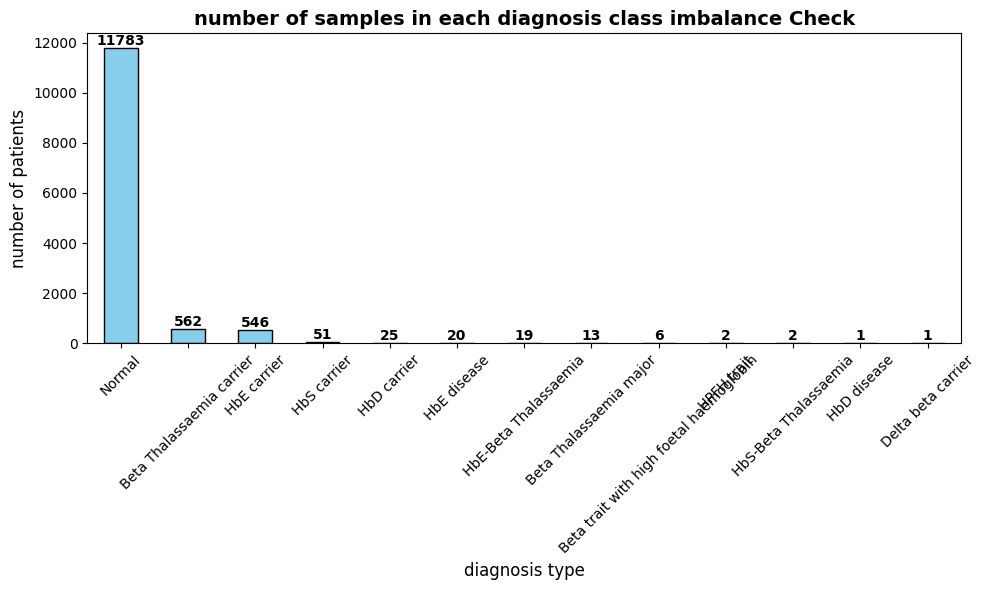

In [30]:
counts=data["Diagnosis"].value_counts()

counts.index=lb.classes_[counts.index]

plt.figure(figsize=(10, 6))
counts.plot(kind='bar',color='skyblue', edgecolor='black')

plt.title('number of samples in each diagnosis class imbalance Check', fontsize=14, fontweight='bold')
plt.xlabel('diagnosis type', fontsize=12)
plt.ylabel('number of patients', fontsize=12)
plt.xticks(rotation=45)

max_val=counts.max()
for index,value in enumerate(counts):
    plt.text(index,value+(max_val*0.01),str(value),ha='center',fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
data.isnull().sum()

Age           0
Gender        0
HbA0          0
HbA2          0
HbF           0
S-Window      0
RBC           0
HB            0
MCV           0
MCH           0
MCHC          0
RDWcv         0
Weekness     10
Jaundice     11
Diagnosis     0
dtype: int64

In [32]:
data=data.dropna()

In [33]:
data.isnull().sum()

Age          0
Gender       0
HbA0         0
HbA2         0
HbF          0
S-Window     0
RBC          0
HB           0
MCV          0
MCH          0
MCHC         0
RDWcv        0
Weekness     0
Jaundice     0
Diagnosis    0
dtype: int64

In [34]:
data["target"]=np.where(data['Diagnosis']==12,0,1)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_31492\534895339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["target"]=np.where(data['Diagnosis']==12,0,1)


In [35]:
print(data["target"].value_counts())

target
0    11771
1     1248
Name: count, dtype: int64


In [36]:
print(data.columns)

Index(['Age', 'Gender', 'HbA0', 'HbA2', 'HbF', 'S-Window', 'RBC', 'HB', 'MCV',
       'MCH', 'MCHC', 'RDWcv', 'Weekness', 'Jaundice', 'Diagnosis', 'target'],
      dtype='object')


In [37]:
data=data.drop(columns=["Diagnosis"])
data

,Age,Gender,HbA0,HbA2,HbF,S-Window,RBC,HB,MCV,MCH,MCHC,RDWcv,Weekness,Jaundice,target
0,63,Female,86.2,2.9,0.3,0.0,4.81,13.2,86.7,28.8,33.0,13.8,No,No,0
1,84,Female,86.4,4.8,0.4,0.0,4.18,10.9,78.9,26.1,33.0,14.6,No,No,1
2,88,Male,87.3,3.2,0.5,0.0,5.31,13.6,87.0,25.6,29.4,13.7,No,No,0
3,154,Female,87.9,2.8,0.2,0.0,4.64,11.5,78.7,44.8,31.5,14.5,No,No,0
4,334,Male,84.3,2.8,0.2,0.0,5.50,14.0,69.7,21.5,30.9,16.5,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,2,Male,79.3,2.9,5.8,0.0,2.07,6.1,89.4,29.5,33.0,19.5,No,No,1
13027,3,Female,77.2,2.7,8.1,0.0,2.47,6.3,81.0,25.5,31.5,16.4,No,No,1
13028,4,Male,21.3,62.9,5.2,0.0,5.26,10.0,60.3,19.0,31.5,24.1,No,No,1
13029,4,Male,87.5,3.3,0.2,0.0,4.60,13.4,84.1,29.1,34.6,14.4,No,No,0


In [39]:
x=data.drop(columns=['target'])
y=data["target"]

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("train shape:",x_train.shape,y_train.shape)
print("test shape:",x_test.shape,y_test.shape)


train shape: (10415, 14) (10415,)
test shape: (2604, 14) (2604,)


In [41]:
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

ValueError: could not convert string to float: 'Female'